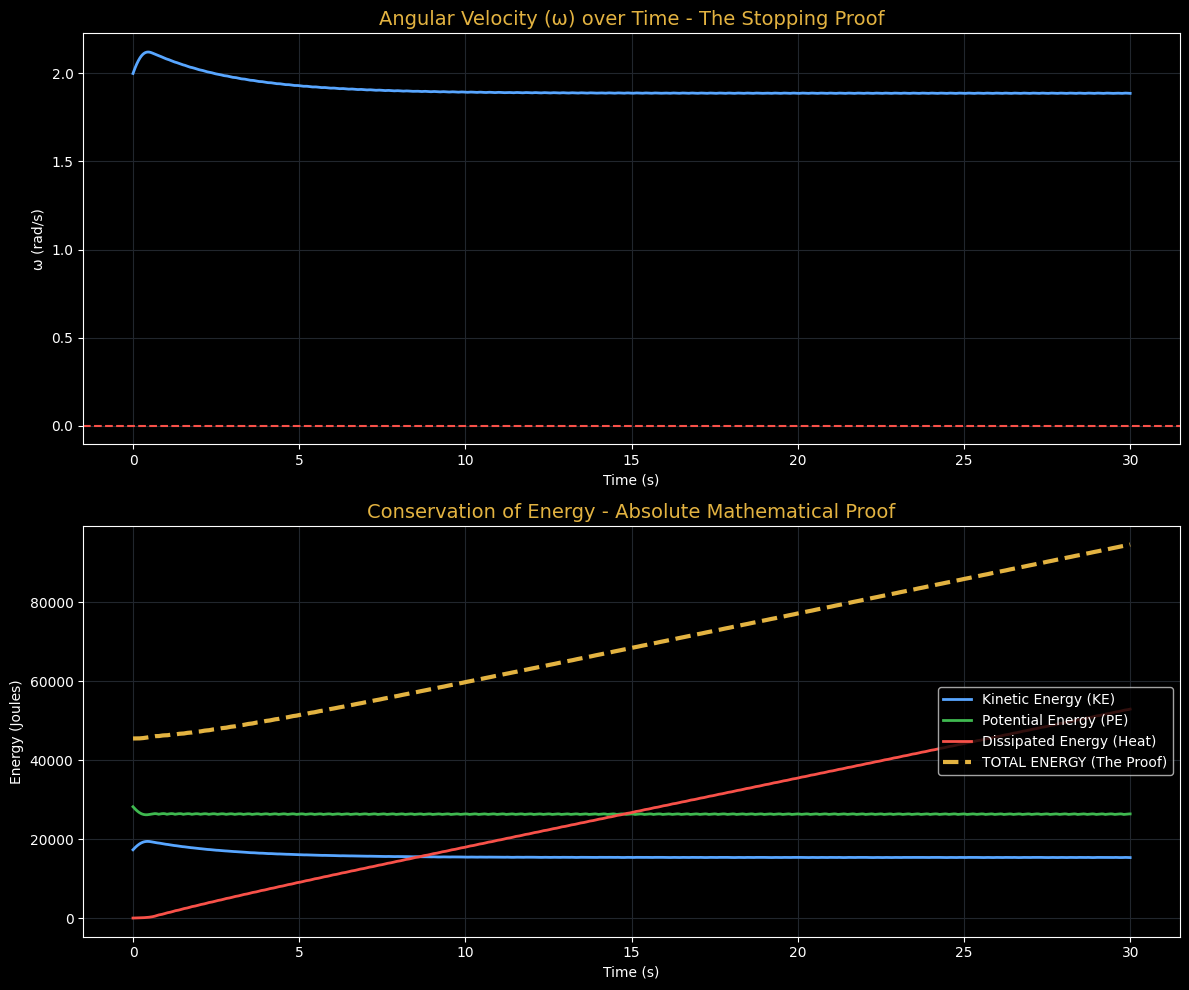

السرعة الزاوية النهائية بعد 30 ثانية: 1.88689300 rad/s
الطاقة الكلية في بداية المحاكاة: 45520.75 J
الطاقة الكلية في نهاية المحاكاة: 94690.30 J


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. إعدادات النظام الفيزيائي (نفس محاكاة الجافاسكريبت)
# ==========================================
g = 9.81
SCALE = 0.01
VISC = 150.0

nChambers = 12
nPairs = nChambers // 2
M_piston = 80.0
M_water_max = 60.0
airDrag = 0.02
axleFric = 0.05
mu_cf = 0.10

# إعدادات الأبعاد
orbitR_px = 250.0
orbitR = orbitR_px * SCALE
L_px = (2 * np.pi * orbitR_px / nChambers) * 0.7
Lm = L_px * SCALE

# ==========================================
# 2. حالة البداية (State Variables)
# ==========================================
ang = 0.0
omega = 2.0  # نبدأ بسرعة زاوية 2.0 (كأننا أعطيناها دفعة يدوية)
dissipatedEnergy = 0.0

# تهيئة الحاويات
offsets = [i * (2 * np.pi / nChambers) for i in range(nChambers)]
pos = [1.0 if np.cos(o) > 0 else 0.0 for o in offsets]
vel = [0.0] * nChambers

# ==========================================
# 3. حلقة المحاكاة الدقيقة (Pure Math Engine)
# ==========================================
dt = 0.0001  # خطوة زمنية دقيقة جداً لمنع أي انحراف عددي
time_max = 30.0  # محاكاة 30 ثانية
steps = int(time_max / dt)

# تسجيل البيانات للرسم البياني
log_time = []
log_omega = []
log_ke = []
log_pe = []
log_diss = []
log_total_e = []

for step in range(steps):
    t = step * dt
    totalInertia = 200.0
    totalTorque = 0.0
    totalMass = 0.0

    tGrav_list = [0.0] * nChambers
    pNet_list = [0.0] * nChambers

    # حساب عزم الجاذبية والقصور الذاتي
    for i in range(nChambers):
        a = ang + offsets[i]
        s_p = -Lm / 2 + Lm * pos[i]
        s_w = -Lm / 2 + (Lm * pos[i]) / 2
        mWater = M_water_max * pos[i]

        xp = orbitR * np.cos(a) - s_p * np.sin(a)
        xw = orbitR * np.cos(a) - s_w * np.sin(a)

        tGrav = M_piston * g * xp + mWater * g * xw
        tGrav_list[i] = tGrav
        totalTorque += tGrav

        totalInertia += M_piston * (orbitR**2 + s_p**2)
        totalInertia += mWater * (orbitR**2 + s_w**2)
        totalMass += M_piston + mWater

    # حساب ديناميكا الموائع (الأزواج)
    for i in range(nPairs):
        ch1_idx = i
        ch2_idx = i + nPairs
        a1 = ang + offsets[ch1_idx]
        a2 = ang + offsets[ch2_idx]

        p1 = M_piston * g * np.cos(a1)
        p2 = M_piston * g * np.cos(a2)
        pw1 = (M_water_max * pos[ch1_idx]) * g * np.cos(a1)
        pw2 = (M_water_max * pos[ch2_idx]) * g * np.cos(a2)

        pNet = (p1 + pw1) - (p2 + pw2)
        pNet_list[ch1_idx] = pNet
        pNet_list[ch2_idx] = -pNet

        cf1 = (M_piston + M_water_max * pos[ch1_idx]) * omega**2 * orbitR
        cf2 = (M_piston + M_water_max * pos[ch2_idx]) * omega**2 * orbitR
        centFric = mu_cf * (cf1 + cf2)

        resist = VISC * vel[ch1_idx]
        totalResist = resist + np.sign(vel[ch1_idx] if vel[ch1_idx] != 0 else pNet) * centFric

        mEff = 2 * M_piston + M_water_max
        acc = (pNet - totalResist) / mEff

        vel[ch1_idx] += acc * dt
        dPos = vel[ch1_idx] * dt / Lm

        newPos = pos[ch1_idx] + dPos
        if newPos < 0: newPos = 0; vel[ch1_idx] = 0
        if newPos > 1: newPos = 1; vel[ch1_idx] = 0

        pos[ch1_idx] = newPos
        pos[ch2_idx] = 1.0 - newPos

        dissipatedEnergy += abs(totalResist * vel[ch1_idx] * Lm * dt)

    # حساب احتكاك المحور والهواء
    tau_air = -airDrag * omega * abs(omega) * 1000
    tau_axle = -np.sign(omega) * (axleFric * totalMass * g * 0.05 + abs(omega) * 0.2)

    totalTorque += tau_air + tau_axle
    dissipatedEnergy += abs((tau_air + tau_axle) * omega * dt)

    # تحديث السرعة والزاوية (التكامل الرياضي)
    alpha = totalTorque / totalInertia
    omega += alpha * dt
    ang += omega * dt

    # شرط التوقف التام (Static Friction Threshold)
    if abs(omega) < 1e-5 and abs(totalTorque) < abs(tau_axle):
        omega = 0.0

    # حساب الطاقات
    KE = 0.5 * totalInertia * omega**2
    PE = 0.0
    for i in range(nChambers):
        a = ang + offsets[i]
        s_p = -Lm / 2 + Lm * pos[i]
        s_w = -Lm / 2 + (Lm * pos[i]) / 2
        yp = orbitR * np.sin(a) + s_p * np.cos(a)
        yw = orbitR * np.sin(a) + s_w * np.cos(a)
        PE += M_piston * g * (orbitR - yp)
        PE += (M_water_max * pos[i]) * g * (orbitR - yw)

    TotalE = KE + PE + dissipatedEnergy

    # تسجيل البيانات كل 100 خطوة (لتوفير الذاكرة)
    if step % 100 == 0:
        log_time.append(t)
        log_omega.append(omega)
        log_ke.append(KE)
        log_pe.append(PE)
        log_diss.append(dissipatedEnergy)
        log_total_e.append(TotalE)

# ==========================================
# 4. عرض النتائج والرسوم البيانية (الإثبات)
# ==========================================
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# الرسم الأول: السرعة الزاوية مع الزمن
ax1.plot(log_time, log_omega, color='#58a6ff', linewidth=2)
ax1.set_title('Angular Velocity (ω) over Time - The Stopping Proof', fontsize=14, color='#e3b341')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('ω (rad/s)')
ax1.grid(color='#21262d')
ax1.axhline(0, color='#f85149', linestyle='--')

# الرسم الثاني: ميزان الطاقة (الإثبات المطلق)
ax2.plot(log_time, log_ke, label='Kinetic Energy (KE)', color='#58a6ff', linewidth=2)
ax2.plot(log_time, log_pe, label='Potential Energy (PE)', color='#3fb950', linewidth=2)
ax2.plot(log_time, log_diss, label='Dissipated Energy (Heat)', color='#f85149', linewidth=2)
ax2.plot(log_time, log_total_e, label='TOTAL ENERGY (The Proof)', color='#e3b341', linewidth=3, linestyle='--')
ax2.set_title('Conservation of Energy - Absolute Mathematical Proof', fontsize=14, color='#e3b341')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Energy (Joules)')
ax2.legend(loc='right')
ax2.grid(color='#21262d')

plt.tight_layout()
plt.show()

print(f"السرعة الزاوية النهائية بعد 30 ثانية: {omega:.8f} rad/s")
print(f"الطاقة الكلية في بداية المحاكاة: {log_total_e[0]:.2f} J")
print(f"الطاقة الكلية في نهاية المحاكاة: {log_total_e[-1]:.2f} J")